In [1]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time
import warnings
from joblib import Parallel, delayed

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# Load and clean the data
# ============================================================
url = "https://data.open-power-system-data.org/time_series/2020-10-06/time_series_60min_singleindex.csv"
load_col = "DE_load_actual_entsoe_transparency"

df = pd.read_csv(url, usecols=["utc_timestamp", load_col])
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp").sort_index()
df = df.rename(columns={load_col: "load_mw"})

# keep only 2015 onwards, drop the single missing value
df = df[df.index >= "2015-01-01"]
df = df.dropna(subset=["load_mw"])

# resample to weekly mean (load is a power reading, so mean not sum)
weekly = df["load_mw"].resample("W").mean().to_frame("load_mw")
series = weekly["load_mw"]

print("Hourly rows:", df.shape[0])
print("Weekly rows:", weekly.shape[0])
print("Date range:", series.index.min(), "to", series.index.max())

df.to_csv("de_load_hourly.csv")
weekly.to_csv("de_load_weekly.csv")

Hourly rows: 50400
Weekly rows: 301
Date range: 2015-01-04 00:00:00+00:00 to 2020-10-04 00:00:00+00:00


--- Original (levels) ---
ADF stat: -4.0475, p-value: 0.0012
KPSS stat: 0.1604, p-value: 0.1000
--- First difference ---
ADF stat: -7.0693, p-value: 0.0000
KPSS stat: 0.0558, p-value: 0.1000
--- Seasonal difference (lag 52) ---
ADF stat: -4.2951, p-value: 0.0005
KPSS stat: 1.3419, p-value: 0.0100

                          series  adf_stat         adf_p  kpss_stat  kpss_p
0             Original (levels) -4.047472  1.181350e-03   0.160374    0.10
1              First difference -7.069318  4.984737e-10   0.055754    0.10
2  Seasonal difference (lag 52) -4.295072  4.530219e-04   1.341877    0.01


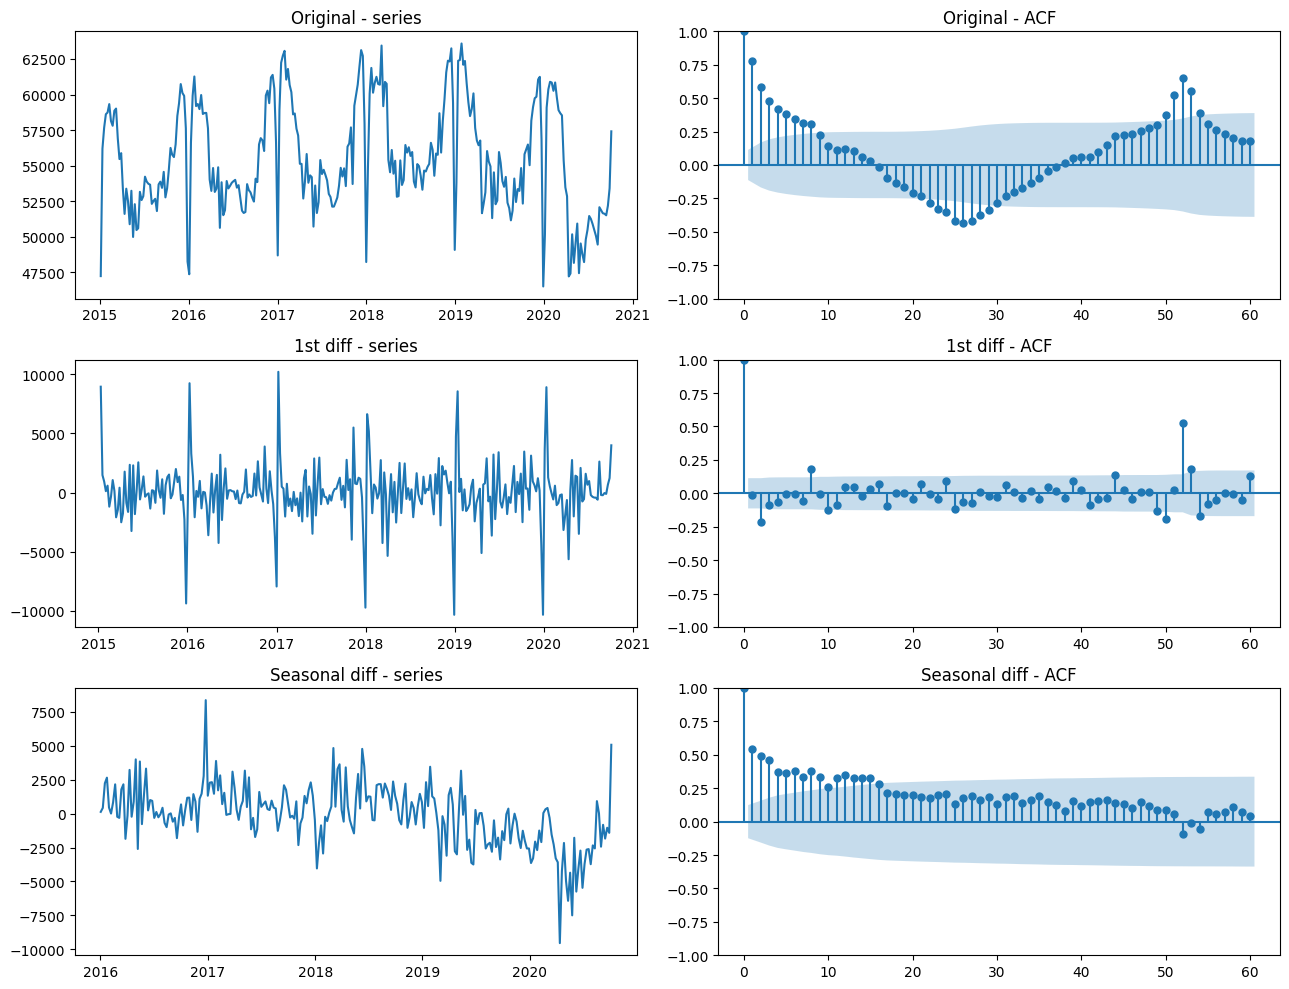

In [3]:
# ============================================================
# Stationarity checks: original series, first difference, seasonal difference
# ============================================================
original = series
first_diff = series.diff().dropna()
seasonal_diff = series.diff(52).dropna()

def run_stationarity_tests(s, label):
    adf_stat, adf_p, *_ = adfuller(s, autolag="AIC")
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    print(f"--- {label} ---")
    print(f"ADF stat: {adf_stat:.4f}, p-value: {adf_p:.4f}")
    print(f"KPSS stat: {kpss_stat:.4f}, p-value: {kpss_p:.4f}")
    return {"series": label, "adf_stat": adf_stat, "adf_p": adf_p,
            "kpss_stat": kpss_stat, "kpss_p": kpss_p}

diff_test_results = [
    run_stationarity_tests(original, "Original (levels)"),
    run_stationarity_tests(first_diff, "First difference"),
    run_stationarity_tests(seasonal_diff, "Seasonal difference (lag 52)"),
]
diff_results_df = pd.DataFrame(diff_test_results)
print("\n", diff_results_df)
diff_results_df.to_csv("differencing_justification_results.csv", index=False)

# plot each version of the series alongside its ACF
fig, axes = plt.subplots(3, 2, figsize=(13, 10))
for i, (s, label) in enumerate([(original, "Original"), (first_diff, "1st diff"), (seasonal_diff, "Seasonal diff")]):
    axes[i, 0].plot(s.index, s.values)
    axes[i, 0].set_title(f"{label} - series")
    plot_acf(s, lags=60, ax=axes[i, 1])
    axes[i, 1].set_title(f"{label} - ACF")
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# Fixed forecast origin and benchmark models
# ============================================================
horizon = 104
train = series.iloc[:-horizon]
test = series.iloc[-horizon:]

mean_forecast = pd.Series(train.mean(), index=test.index)
naive_forecast = pd.Series(train.iloc[-1], index=test.index)
last_season = train.iloc[-52:].values
seasonal_naive_forecast = pd.Series(np.tile(last_season, 2)[:horizon], index=test.index)
drift_slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
drift_forecast = pd.Series(train.iloc[-1] + drift_slope * np.arange(1, horizon + 1), index=test.index)

def compute_errors(actual, predicted):
    error = actual - predicted
    return np.sqrt((error ** 2).mean()), error.abs().mean()

benchmarks = {"mean": mean_forecast, "naive": naive_forecast,
              "seasonal_naive": seasonal_naive_forecast, "drift": drift_forecast}

benchmark_results = []
for name, forecast in benchmarks.items():
    rmse, mae = compute_errors(test, forecast)
    benchmark_results.append({"model": name, "rmse": rmse, "mae": mae})

benchmark_df = pd.DataFrame(benchmark_results)
print(benchmark_df)
benchmark_df.to_csv("benchmark_results.csv", index=False)

seasonal_naive_rmse = benchmark_df.loc[benchmark_df["model"] == "seasonal_naive", "rmse"].values[0]

            model         rmse          mae
0            mean  4397.299694  3788.833122
1           naive  4459.108546  3783.202934
2  seasonal_naive  3006.760812  2318.520585
3           drift  5117.957264  4339.890674


In [5]:
# ============================================================
# SARIMA grid search - full p,d,q range, run in parallel, stability enforced
# ============================================================
# seasonal order fixed from the ACF/PACF evidence above (spike at lag 52),
# rather than grid searched, to keep runtime manageable
seasonal_order_fixed = (1, 0, 1, 52)

p_values, d_values, q_values = range(0, 7), range(0, 3), range(0, 7)
combinations = list(itertools.product(p_values, d_values, q_values))
print(f"Total combinations: {len(combinations)}")

def fit_candidate(order):
    try:
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order_fixed,
                         enforce_stationarity=True, enforce_invertibility=True)
        fit = model.fit(disp=False, maxiter=50, method="lbfgs")
        return {"order": order, "aic": fit.aic}
    except Exception:
        return None

start_time = time.time()
raw_results = Parallel(n_jobs=-1, verbose=5)(delayed(fit_candidate)(o) for o in combinations)
print(f"Grid search took {time.time() - start_time:.1f} seconds")

search_df = pd.DataFrame([r for r in raw_results if r is not None]).sort_values("aic").reset_index(drop=True)
search_df.to_csv("sarima_grid_search_results.csv", index=False)
print(search_df.head())

best_order = search_df.iloc[0]["order"]
print("Best order:", best_order, "AIC:", search_df.iloc[0]["aic"])

Total combinations: 147


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   37.4s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:  4.7min


Grid search took 787.9 seconds
       order          aic
0  (2, 0, 2)  3515.156917
1  (2, 0, 3)  3516.996709
2  (1, 0, 2)  3517.340300
3  (1, 0, 3)  3518.955916
4  (5, 0, 1)  3522.270643
Best order: (2, 0, 2) AIC: 3515.15691734548


[Parallel(n_jobs=-1)]: Done 147 out of 147 | elapsed: 13.1min finished


       order    train_aic    test_rmse     test_mae  ljungbox_p  \
0  (2, 0, 2)  3515.156917  3462.855299  2759.797554    0.701970   
1  (2, 0, 3)  3516.996709  2980.844636  2318.175161    0.677526   
2  (1, 0, 2)  3517.340300  2904.454359  2264.486610    0.615646   
3  (1, 0, 3)  3518.955916  3116.063754  2445.823572    0.519108   
4  (5, 0, 1)  3522.270643  3153.153898  2409.571442    0.865941   

   residual_bias  aic_rank  rmse_rank  rank_agreement  
0     445.406455       1.0        5.0            -4.0  
1     472.446203       2.0        2.0             0.0  
2     385.407034       3.0        1.0             2.0  
3     375.180923       4.0        3.0             1.0  
4     531.098878       5.0        4.0             1.0  


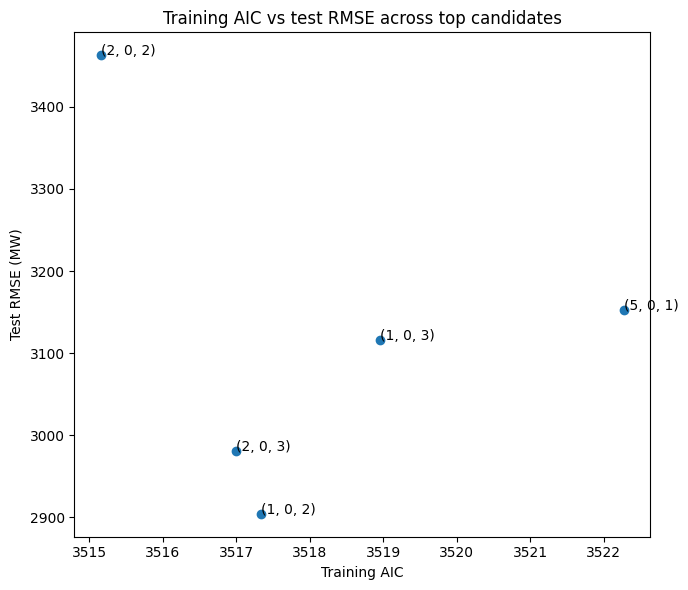

In [6]:
# ============================================================
# Compare top 5 AIC candidates against test-set forecasting accuracy
# ============================================================
top5 = search_df.head(5).copy()
candidate_results = []

for _, row in top5.iterrows():
    order = row["order"]
    model = SARIMAX(train, order=order, seasonal_order=seasonal_order_fixed,
                     enforce_stationarity=True, enforce_invertibility=True)
    fit = model.fit(disp=False)
    forecast = fit.get_forecast(steps=horizon).predicted_mean
    rmse, mae = compute_errors(test, forecast)
    residuals = fit.resid
    lb_p = acorr_ljungbox(residuals, lags=[20], return_df=True)["lb_pvalue"].iloc[0]

    candidate_results.append({
        "order": order, "train_aic": row["aic"], "test_rmse": rmse,
        "test_mae": mae, "ljungbox_p": lb_p, "residual_bias": residuals.mean(),
    })

results_df = pd.DataFrame(candidate_results)
results_df["aic_rank"] = results_df["train_aic"].rank()
results_df["rmse_rank"] = results_df["test_rmse"].rank()
results_df["rank_agreement"] = results_df["aic_rank"] - results_df["rmse_rank"]
print(results_df)
results_df.to_csv("sarima_aic_vs_rmse_comparison.csv", index=False)

# scatter plot: does lower training AIC actually mean lower test error?
plt.figure(figsize=(7, 6))
plt.scatter(results_df["train_aic"], results_df["test_rmse"])
for _, r in results_df.iterrows():
    plt.annotate(str(r["order"]), (r["train_aic"], r["test_rmse"]))
plt.xlabel("Training AIC")
plt.ylabel("Test RMSE (MW)")
plt.title("Training AIC vs test RMSE across top candidates")
plt.tight_layout()
plt.show()

                                      SARIMAX Results                                       
Dep. Variable:                              load_mw   No. Observations:                  197
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 52)   Log Likelihood               -1750.578
Date:                              Sun, 12 Jul 2026   AIC                           3515.157
Time:                                      11:08:33   BIC                           3538.139
Sample:                                  01-04-2015   HQIC                          3524.460
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7365      0.095     18.356      0.000       1.551       1.922
ar.L2         -0.73

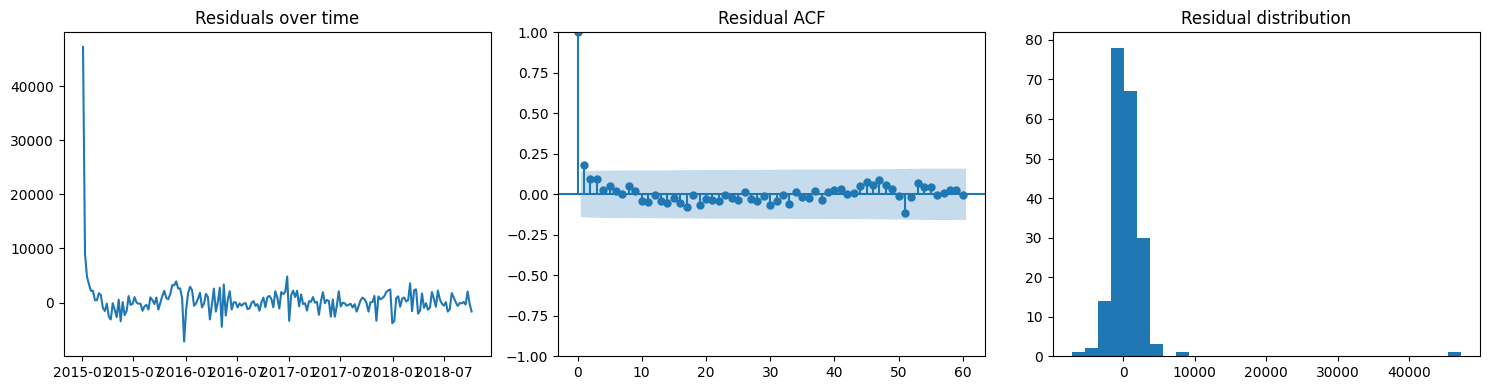

      lb_stat  lb_pvalue
10  11.701266   0.305547
20  16.234555   0.701970
30  18.894712   0.942185
SARIMA test RMSE: 3462.8552988909073 MAE: 2759.7975539181834


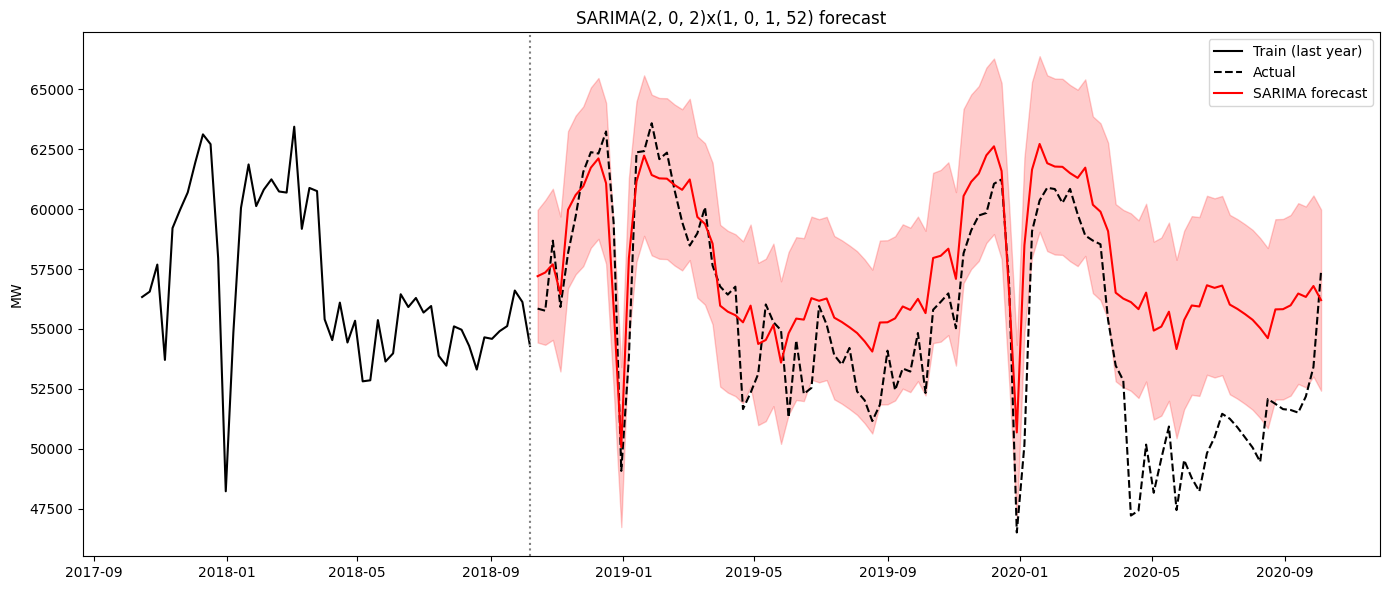

In [7]:
# ============================================================
# Fit and forecast with the final selected SARIMA model
# ============================================================
final_model = SARIMAX(train, order=best_order, seasonal_order=seasonal_order_fixed,
                       enforce_stationarity=True, enforce_invertibility=True)
final_fit = final_model.fit(disp=False)
print(final_fit.summary())

# check AR roots - all should have modulus > 1 for a stable forecast
ar_roots = final_fit.arroots
print("AR roots (modulus):", np.abs(ar_roots))

residuals = final_fit.resid
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(residuals)
axes[0].set_title("Residuals over time")
plot_acf(residuals, lags=60, ax=axes[1])
axes[1].set_title("Residual ACF")
axes[2].hist(residuals, bins=30)
axes[2].set_title("Residual distribution")
plt.tight_layout()
plt.show()

lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print(lb_test)

forecast_result = final_fit.get_forecast(steps=horizon)
sarima_forecast = forecast_result.predicted_mean
sarima_ci = forecast_result.conf_int(alpha=0.05)

sarima_rmse, sarima_mae = compute_errors(test, sarima_forecast)
print("SARIMA test RMSE:", sarima_rmse, "MAE:", sarima_mae)

plt.figure(figsize=(14, 6))
plt.plot(train.index[-52:], train.iloc[-52:], label="Train (last year)", color="black")
plt.plot(test.index, test, label="Actual", color="black", linestyle="--")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA forecast", color="red")
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color="red", alpha=0.2)
plt.axvline(train.index[-1], color="grey", linestyle=":")
plt.legend()
plt.title(f"SARIMA{best_order}x{seasonal_order_fixed} forecast")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

sarima_forecast.to_csv("sarima_forecast.csv")
sarima_ci.to_csv("sarima_forecast_ci.csv")

In [9]:
# ============================================================
# Add temperature and fit SARIMAX
# ============================================================
import requests
start_date = series.index.min().strftime("%Y-%m-%d")
end_date = series.index.max().strftime("%Y-%m-%d")

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude=52.52&longitude=13.405"
    f"&start_date={start_date}&end_date={end_date}"
    "&daily=temperature_2m_mean&timezone=Europe%2FBerlin"
)
response = requests.get(url)
response.raise_for_status()
temp_json = response.json()

temp_daily = pd.DataFrame({
    "date": pd.to_datetime(temp_json["daily"]["time"]),
    "temp_mean": temp_json["daily"]["temperature_2m_mean"],
}).set_index("date")

temp_weekly = temp_daily["temp_mean"].resample("W").mean()

# align tz-aware series index with tz-naive temperature index
series_index_naive = series.index.tz_localize(None)
temp_weekly = temp_weekly.reindex(series_index_naive)
temp_weekly.index = series.index
temp_weekly = temp_weekly.interpolate()

print("NaNs after alignment:", temp_weekly.isna().sum())

temp_train = temp_weekly.iloc[:-horizon]
temp_test = temp_weekly.iloc[-horizon:]

# note: this uses observed test-period temperature, so it is a conditional
# forecast rather than a true operational one - temperature is not known
# in advance unless it comes from a weather forecast itself
sarimax_model = SARIMAX(train, exog=temp_train, order=best_order, seasonal_order=seasonal_order_fixed,
                         enforce_stationarity=True, enforce_invertibility=True)
sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

sarimax_forecast_result = sarimax_fit.get_forecast(steps=horizon, exog=temp_test)
sarimax_forecast = sarimax_forecast_result.predicted_mean
sarimax_ci = sarimax_forecast_result.conf_int(alpha=0.05)

sarimax_rmse, sarimax_mae = compute_errors(test, sarimax_forecast)
print("SARIMAX test RMSE:", sarimax_rmse, "MAE:", sarimax_mae)

temp_weekly.to_csv("berlin_temperature_weekly.csv")
sarimax_forecast.to_csv("sarimax_forecast.csv")

NaNs after alignment: 0
                                      SARIMAX Results                                       
Dep. Variable:                              load_mw   No. Observations:                  197
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 52)   Log Likelihood               -2012.274
Date:                              Sun, 12 Jul 2026   AIC                           4040.549
Time:                                      11:45:32   BIC                           4066.814
Sample:                                  01-04-2015   HQIC                          4051.181
                                       - 10-07-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp_mean   -263.3054   1035.219     -0.254      0.799   -2292.297    1765

In [10]:
# ============================================================
# Random Forest - kept simple, as a secondary nonlinear check only
# ============================================================
feature_df = pd.DataFrame({"load": series, "temp": temp_weekly})
feature_df["lag_1"] = feature_df["load"].shift(1)
feature_df["lag_2"] = feature_df["load"].shift(2)
feature_df["lag_52"] = feature_df["load"].shift(52)
feature_df = feature_df.dropna()

feature_cols = ["lag_1", "lag_2", "lag_52", "temp"]
train_features = feature_df[feature_df.index <= train.index[-1]]

rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(train_features[feature_cols], train_features["load"])

# recursive forecast: feed each prediction back in as the next lag
history = series.copy()
rf_predictions = []
for forecast_date in test.index:
    lag_1 = history.loc[:forecast_date].iloc[-1]
    lag_2 = history.loc[:forecast_date].iloc[-2]
    lag_52_idx = history.index.get_loc(forecast_date) - 52
    lag_52 = history.iloc[lag_52_idx]
    temp_val = temp_weekly.loc[forecast_date]

    x_step = pd.DataFrame([{"lag_1": lag_1, "lag_2": lag_2, "lag_52": lag_52, "temp": temp_val}])[feature_cols]
    pred = rf_model.predict(x_step)[0]
    rf_predictions.append(pred)
    history.loc[forecast_date] = pred

rf_forecast = pd.Series(rf_predictions, index=test.index)
rf_rmse, rf_mae = compute_errors(test, rf_forecast)
print("Random Forest test RMSE:", rf_rmse, "MAE:", rf_mae)

rf_forecast.to_csv("rf_forecast.csv")

Random Forest test RMSE: 2662.444572024534 MAE: 1919.3408835674022


In [11]:
# ============================================================
# LSTM - kept small and fixed, as a secondary comparison only
# ============================================================
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

hourly_load = df["load_mw"]
horizon_hours = horizon * 7 * 24
train_hourly = hourly_load.iloc[:-horizon_hours]
test_hourly = hourly_load.iloc[-horizon_hours:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_hourly.values.reshape(-1, 1))

def build_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

seq_len = 168
X_train, y_train = build_sequences(train_scaled, seq_len)
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model = LSTMForecaster().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

batch_size = 256
n_epochs = 10
n_batches = len(X_train_t) // batch_size

for epoch in range(n_epochs):
    perm = torch.randperm(len(X_train_t))
    epoch_loss = 0.0
    for i in range(n_batches):
        idx = perm[i * batch_size:(i + 1) * batch_size]
        xb, yb = X_train_t[idx], y_train_t[idx]
        optimizer.zero_grad()
        pred = model(xb).squeeze()
        loss = criterion(pred, yb.squeeze())
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs} - loss: {epoch_loss / n_batches:.6f}")

model.eval()
history_scaled = list(train_scaled[-seq_len:].flatten())
lstm_predictions_scaled = []
with torch.no_grad():
    for _ in range(len(test_hourly)):
        seq = torch.tensor(history_scaled[-seq_len:], dtype=torch.float32).reshape(1, seq_len, 1).to(device)
        pred = model(seq).item()
        lstm_predictions_scaled.append(pred)
        history_scaled.append(pred)

lstm_predictions = scaler.inverse_transform(np.array(lstm_predictions_scaled).reshape(-1, 1)).flatten()
lstm_forecast_hourly = pd.Series(lstm_predictions, index=test_hourly.index)
lstm_forecast_weekly = lstm_forecast_hourly.resample("W").mean()

lstm_rmse, lstm_mae = compute_errors(test, lstm_forecast_weekly)
print("LSTM test RMSE:", lstm_rmse, "MAE:", lstm_mae)

lstm_forecast_weekly.to_csv("lstm_forecast_weekly.csv")

Using device: cuda
Epoch 1/10 - loss: 0.082681
Epoch 2/10 - loss: 0.020992
Epoch 3/10 - loss: 0.011116
Epoch 4/10 - loss: 0.007158
Epoch 5/10 - loss: 0.003176
Epoch 6/10 - loss: 0.002497
Epoch 7/10 - loss: 0.002246
Epoch 8/10 - loss: 0.002036
Epoch 9/10 - loss: 0.001795
Epoch 10/10 - loss: 0.001594
LSTM test RMSE: 14256.11549403453 MAE: 13559.289958076419


In [12]:
# ============================================================
# Final comparison: every model against seasonal naive
# ============================================================
final_comparison = pd.DataFrame([
    {"model": "seasonal_naive", "rmse": seasonal_naive_rmse},
    {"model": "SARIMA", "rmse": sarima_rmse},
    {"model": "SARIMAX", "rmse": sarimax_rmse},
    {"model": "RandomForest", "rmse": rf_rmse},
    {"model": "LSTM", "rmse": lstm_rmse},
])
final_comparison["pct_improvement_vs_seasonal_naive"] = (
    (seasonal_naive_rmse - final_comparison["rmse"]) / seasonal_naive_rmse * 100
)
print(final_comparison)
final_comparison.to_csv("final_model_comparison.csv", index=False)

            model          rmse  pct_improvement_vs_seasonal_naive
0  seasonal_naive   3006.760812                           0.000000
1          SARIMA   3462.855299                         -15.168965
2         SARIMAX   3917.566738                         -30.291932
3    RandomForest   2662.444572                          11.451401
4            LSTM  14256.115494                        -374.135337


LSTM weekly forecast length: 104 vs test length: 104
NaNs after alignment: 0


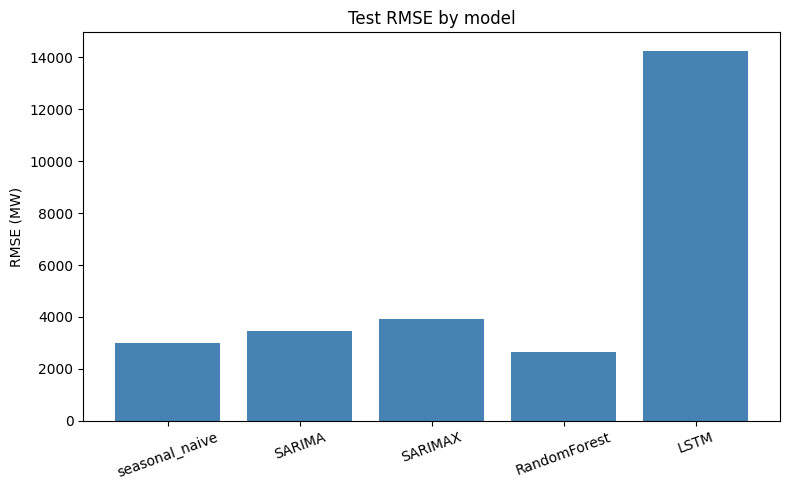

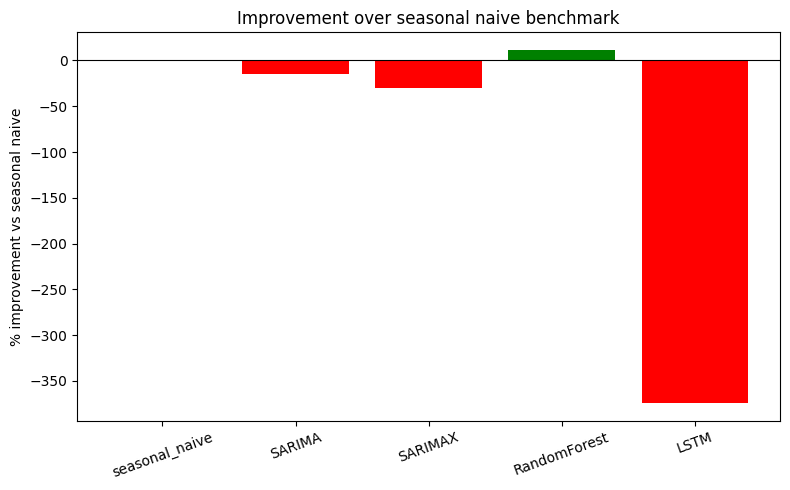

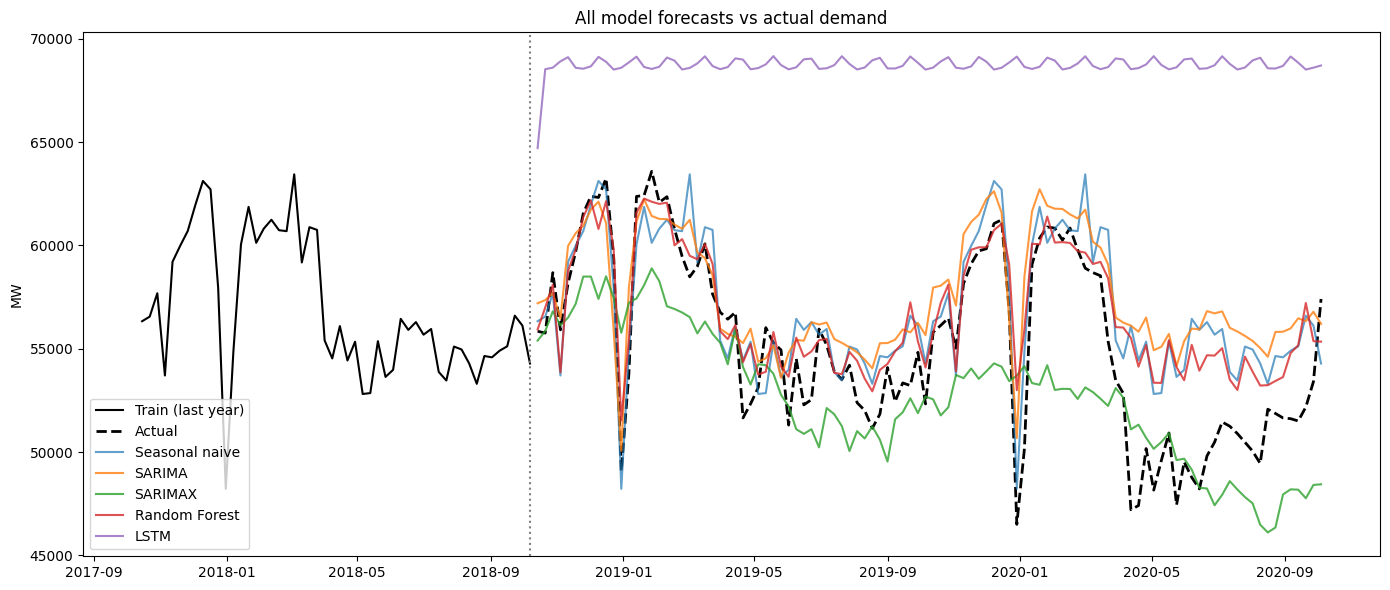

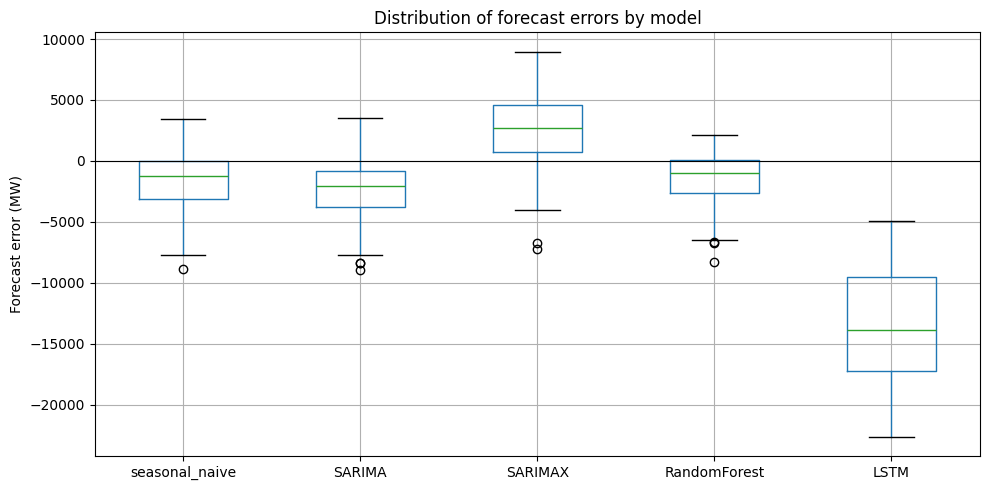

In [14]:
# ============================================================
# Evaluation plots for the final model comparison
# ============================================================

# --- align LSTM weekly forecast to the exact test index before using it anywhere ---
lstm_forecast_weekly = lstm_forecast_weekly.reindex(test.index)
print("LSTM weekly forecast length:", len(lstm_forecast_weekly), "vs test length:", len(test))
print("NaNs after alignment:", lstm_forecast_weekly.isna().sum())

# --- Bar chart: RMSE by model ---
plt.figure(figsize=(8, 5))
plt.bar(final_comparison["model"], final_comparison["rmse"], color="steelblue")
plt.ylabel("RMSE (MW)")
plt.title("Test RMSE by model")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# --- Bar chart: % improvement over seasonal naive ---
plt.figure(figsize=(8, 5))
colors = ["grey" if m == "seasonal_naive" else ("green" if v > 0 else "red")
          for m, v in zip(final_comparison["model"], final_comparison["pct_improvement_vs_seasonal_naive"])]
plt.bar(final_comparison["model"], final_comparison["pct_improvement_vs_seasonal_naive"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("% improvement vs seasonal naive")
plt.title("Improvement over seasonal naive benchmark")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# --- Overlay plot: all forecasts against actual test data ---
plt.figure(figsize=(14, 6))
plt.plot(train.index[-52:], train.iloc[-52:], label="Train (last year)", color="black")
plt.plot(test.index, test, label="Actual", color="black", linestyle="--", linewidth=2)
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal naive", alpha=0.7)
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA", alpha=0.8)
plt.plot(sarimax_forecast.index, sarimax_forecast, label="SARIMAX", alpha=0.8)
plt.plot(rf_forecast.index, rf_forecast, label="Random Forest", alpha=0.8)
plt.plot(lstm_forecast_weekly.index, lstm_forecast_weekly, label="LSTM", alpha=0.8)
plt.axvline(train.index[-1], color="grey", linestyle=":")
plt.legend()
plt.title("All model forecasts vs actual demand")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

# --- Residual (error) comparison across models ---
errors_df = pd.DataFrame({
    "seasonal_naive": (test.values - seasonal_naive_forecast.values),
    "SARIMA": (test.values - sarima_forecast.values),
    "SARIMAX": (test.values - sarimax_forecast.values),
    "RandomForest": (test.values - rf_forecast.values),
    "LSTM": (test.values - lstm_forecast_weekly.values),
}, index=test.index)

plt.figure(figsize=(10, 5))
errors_df.boxplot()
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Forecast error (MW)")
plt.title("Distribution of forecast errors by model")
plt.tight_layout()
plt.show()

errors_df.to_csv("model_errors_comparison.csv")